In [2]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
rep="/Users/gilles/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/WordStructure/"
fStatistiques="vlexique2-Statistiques.yaml"
with open(rep+fStatistiques,"r") as inFile:
         stats=yaml.safe_load(inFile)

In [4]:
def getPR(k):
    kG=stats[k]["gold"]
    corrG=kG["nbCorrect"]
    diffG=kG["nbDifferent"]
    missG=kG["nbMissing"]
    recallG=corrG/(corrG+diffG+missG)
    precisionG=corrG/(corrG+diffG)

    kP=stats[k]["platinum"]
    corrP=kP["nbCorrect"]
    diffP=kP["nbDifferent"]
    missP=kP["nbMissing"]
    recallP=corrP/(corrP+diffP+missP)
    precisionP=corrP/(corrP+diffP)

    return recallG,precisionG,recallP,precisionP

# Direct

{80: (0.9806352425501292, 0.9829180327868853, 0.8277799206181334, 0.9597308175011902), 70: (0.9789436695859012, 0.9819429005232763, 0.8232075354774742, 0.9626089666016913), 60: (0.9765544012880742, 0.9800562232994665, 0.8108119755465397, 0.9621639392168323), 50: (0.9725855751523551, 0.9771305409323262, 0.7898680907614313, 0.9599946160978674), 40: (0.9679881315420753, 0.9748173970783532, 0.7688383469394238, 0.9575045494105546), 30: (0.9538897128218956, 0.9672788588615959, 0.7519499517989443, 0.9547049660201654), 20: (0.924029872602138, 0.9505460570912103, 0.7214840204088021, 0.9436938320129379), 10: (0.8586905661735593, 0.9323146664582438, 0.6622800251569342, 0.9291921949920086)}


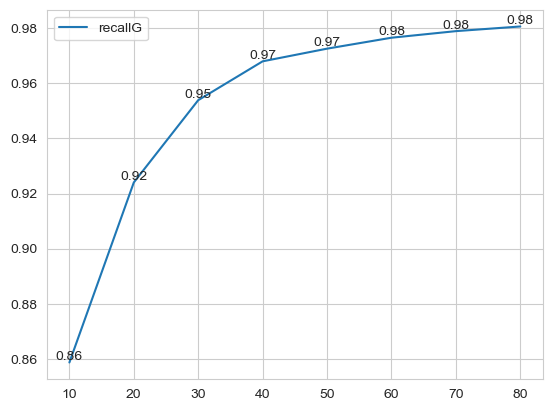

In [12]:
dPR={}
for i in range(1,9):
    dPR[100-10*(i+1)]=getPR("Direct-S%d"%i)
print(dPR)
dfPR=pd.DataFrame(dPR).T
dfPR.columns=["recallG","precisionG","recallP","precisionP"]
ax=dfPR[["recallG"]].plot()
for i,j in zip(dfPR.index,dfPR.recallG):
    ax.annotate(str(round(j,2)),xy=(i,j+.001),ha='center')

# dfPR

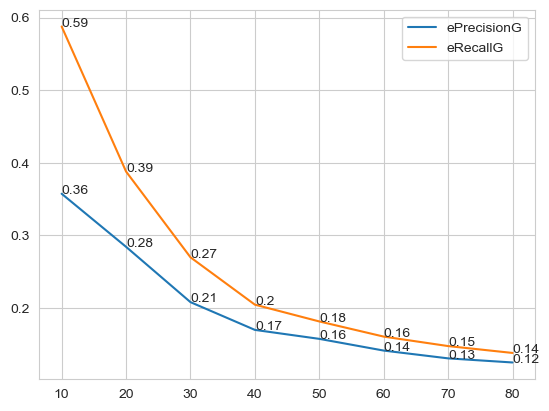

In [59]:
dfEntropyPR=dfPR.copy()
dfEntropyPR["eRecallG"]=entropy([dfEntropyPR["recallG"],1-dfEntropyPR["recallG"]],base=2)
dfEntropyPR["ePrecisionG"]=entropy([dfEntropyPR["precisionG"],1-dfEntropyPR["precisionG"]],base=2)
dfEntropyPR["eRecallP"]=entropy([dfEntropyPR["recallP"],1-dfEntropyPR["recallP"]],base=2)
dfEntropyPR["ePrecisionP"]=entropy([dfEntropyPR["precisionP"],1-dfEntropyPR["precisionP"]],base=2)
ax=dfEntropyPR[["ePrecisionG","eRecallG"]].plot()
for i,j in zip(dfEntropyPR.index,dfEntropyPR.eRecallG):
    ax.annotate(str(round(j,2)),xy=(i,j))
for i,j in zip(dfEntropyPR.index,dfEntropyPR.ePrecisionG):
    ax.annotate(str(round(j,2)),xy=(i,j))

# Swim

{80: (0.9841633400955435, 0.9980753915582692, 0.8322112120778031, 0.9942999590728132), 70: (0.9802060517563073, 0.9971117346096716, 0.8308605525300518, 0.9931787681745049), 60: (0.9758804837143614, 0.9967768110715413, 0.8149556088153931, 0.9627977057008094), 50: (0.9695081406615119, 0.9961350771032598, 0.7959328169829211, 0.9626201627735541), 40: (0.962144954310032, 0.9952567011892371, 0.7790098808448949, 0.9907650008086689), 30: (0.9486975810077636, 0.9932059248101425, 0.7545504837208047, 0.9884141222217313), 20: (0.9146738174784597, 0.9863630617533657, 0.714530623747495, 0.9806506371000666), 10: (0.8446521512057198, 0.9736760156947414, 0.6537279061761808, 0.9701581932847126)}


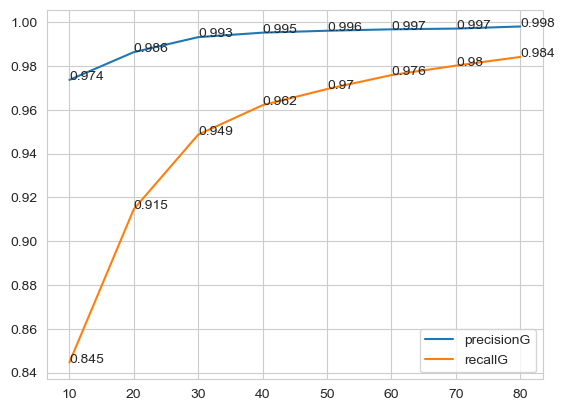

In [60]:
dPR={}
for i in range(1,9):
    dPR[100-10*(i+1)]=getPR("S%d-StemSpace"%i)
print(dPR)
dfPR=pd.DataFrame(dPR).T
dfPR.columns=["recallG","precisionG","recallP","precisionP"]
ax=dfPR[["precisionG","recallG"]].plot()
for i,j in zip(dfPR.index,dfPR.precisionG):
    ax.annotate(str(round(j,3)),xy=(i,j))
for i,j in zip(dfPR.index,dfPR.recallG):
    ax.annotate(str(round(j,3)),xy=(i,j))
# dfPR

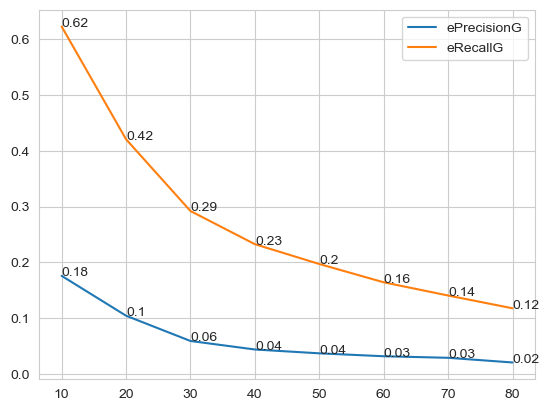

In [61]:
dfEntropyPR=dfPR.copy()
dfEntropyPR["eRecallG"]=entropy([dfEntropyPR["recallG"],1-dfEntropyPR["recallG"]],base=2)
dfEntropyPR["ePrecisionG"]=entropy([dfEntropyPR["precisionG"],1-dfEntropyPR["precisionG"]],base=2)
dfEntropyPR["eRecallP"]=entropy([dfEntropyPR["recallP"],1-dfEntropyPR["recallP"]],base=2)
dfEntropyPR["ePrecisionP"]=entropy([dfEntropyPR["precisionP"],1-dfEntropyPR["precisionP"]],base=2)
ax=dfEntropyPR[["ePrecisionG","eRecallG"]].plot()
for i,j in zip(dfEntropyPR.index,dfEntropyPR.eRecallG):
    ax.annotate(str(round(j,2)),xy=(i,j))
for i,j in zip(dfEntropyPR.index,dfEntropyPR.ePrecisionG):
    ax.annotate(str(round(j,2)),xy=(i,j))